In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('Data/Restaurant_sales.csv', parse_dates=['date'])
df

,date,item,sales,is_weekend,is_holiday,is_festival,promo_active,temperature_celsius,rainfall_mm
0,2022-01-01,Burger,224,1,0,1,0,21.6,0.3
1,2022-01-01,Pizza,164,1,0,1,0,21.6,0.3
2,2022-01-01,Pasta,149,1,0,1,0,21.6,0.3
3,2022-01-01,Salad,98,1,0,1,0,21.6,0.3
4,2022-01-02,Burger,112,1,0,0,0,22.2,0.2
...,...,...,...,...,...,...,...,...,...
2915,2023-12-30,Salad,81,1,0,0,1,16.4,0.2
2916,2023-12-31,Burger,191,1,0,0,1,18.1,3.4
2917,2023-12-31,Pizza,144,1,0,0,1,18.1,3.4
2918,2023-12-31,Pasta,129,1,0,0,1,18.1,3.4


In [3]:
df = df[df['item'] == 'Burger']

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (730, 9)
Columns: ['date', 'item', 'sales', 'is_weekend', 'is_holiday', 'is_festival', 'promo_active', 'temperature_celsius', 'rainfall_mm']


,date,item,sales,is_weekend,is_holiday,is_festival,promo_active,temperature_celsius,rainfall_mm
0,2022-01-01,Burger,224,1,0,1,0,21.6,0.3
4,2022-01-02,Burger,112,1,0,0,0,22.2,0.2
8,2022-01-03,Burger,70,0,0,0,0,21.3,0.1
12,2022-01-04,Burger,100,0,0,0,0,20.1,0.1
16,2022-01-05,Burger,88,0,0,0,0,20.3,0.2


## **Calendar Features**

##### Add time-based calendar features

In [21]:
def add_calendar_features(df):
    df = df.copy()

    df["day_of_week"] = df.index.dayofweek
    df["day_of_month"] = df.index.day
    df["month"] = df.index.month
    df["quarter"] = df.index.quarter
    df["week_of_year"] = df.index.isocalendar().week.astype(int)
    df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)
    df["day_name"] = df.index.day_name()

    return df

##### Visualize: average sales by each calendar feature

Calendar features added:
            day_of_week  day_of_month  month  quarter  week_of_year  \
date                                                                  
2022-01-01            5             1      1        1            52   
2022-01-02            6             2      1        1            52   
2022-01-03            0             3      1        1             1   
2022-01-04            1             4      1        1             1   
2022-01-05            2             5      1        1             1   
2022-01-06            3             6      1        1             1   
2022-01-07            4             7      1        1             1   
2022-01-08            5             8      1        1             1   
2022-01-09            6             9      1        1             1   
2022-01-10            0            10      1        1             2   

            is_weekend  
date                    
2022-01-01           1  
2022-01-02           1  
2022-01-03           0

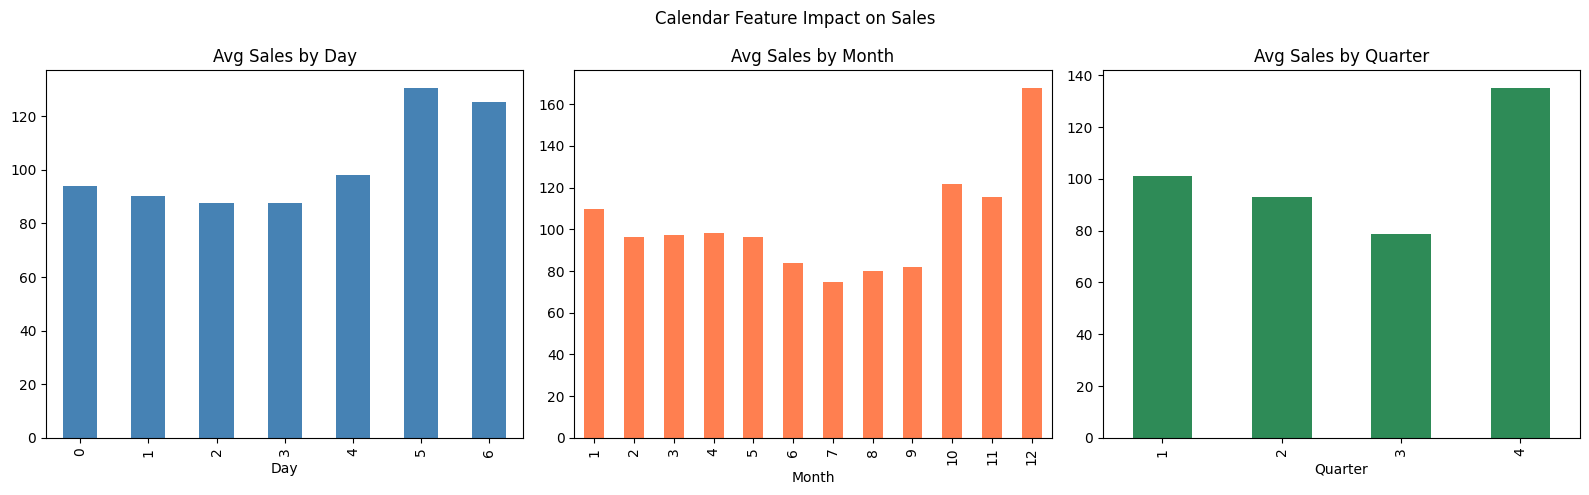

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load data
df = load_data(item='Burger')

# Add calendar features
df = add_calendar_features(df)

print("Calendar features added:")

cols = ['day_of_week', 'day_of_month', 'month',
        'quarter', 'week_of_year', 'is_weekend']

print(df[cols].head(10))

# Create plots
plt.figure(figsize=(16,5))

# Day of week
plt.subplot(1,3,1)
df.groupby('day_of_week')['sales'].mean().plot(kind='bar', color='steelblue')
plt.title('Avg Sales by Day')
plt.xlabel('Day')

# Month
plt.subplot(1,3,2)
df.groupby('month')['sales'].mean().plot(kind='bar', color='coral')
plt.title('Avg Sales by Month')
plt.xlabel('Month')

# Quarter
plt.subplot(1,3,3)
df.groupby('quarter')['sales'].mean().plot(kind='bar', color='seagreen')
plt.title('Avg Sales by Quarter')
plt.xlabel('Quarter')

plt.suptitle('Calendar Feature Impact on Sales')
plt.tight_layout()

# Save
os.makedirs('reports', exist_ok=True)
plt.savefig('reports/07_calendar_features.png')

plt.show()


## **Lag Features**

In [25]:
def add_lag_features(df, column="sales", lags=[1, 7, 14, 21, 28]):
    df = df.copy()

    for lag in lags:
        df["lag_" + str(lag)] = df[column].shift(lag)

    return df

##### Add lag features

In [26]:
df = add_lag_features(df, lags=[1,7,14,21,28])

lag_cols = ['sales','lag_1','lag_7','lag_14','lag_21','lag_28']
print("Lag features (first 10 rows after NaN drop):")
print(df[lag_cols].dropna().head(10).to_string())

Lag features (first 10 rows after NaN drop):
            sales  lag_1  lag_7  lag_14  lag_21  lag_28
date                                                   
2022-01-29    136  104.0  145.0   119.0   121.0   224.0
2022-01-30    128  136.0  112.0   120.0   114.0   112.0
2022-01-31     79  128.0   78.0    74.0    80.0    70.0
2022-02-01     74   79.0   84.0    86.0    86.0   100.0
2022-02-02     78   74.0  118.0    85.0    91.0    88.0
2022-02-03     73   78.0   76.0    88.0   101.0    87.0
2022-02-04     90   73.0  104.0    87.0    99.0    81.0
2022-02-05    121   90.0  136.0   145.0   119.0   121.0
2022-02-06    106  121.0  128.0   112.0   120.0   114.0
2022-02-07     83  106.0   79.0    78.0    74.0    80.0


##### Correlation of lag features vs target

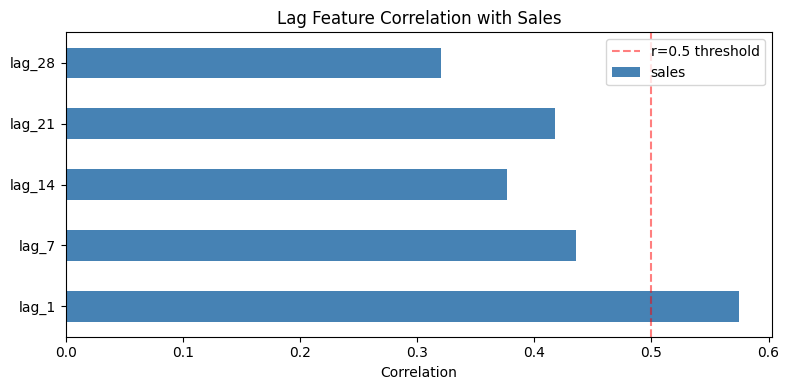

lag_7 usually has highest correlation because of weekly pattern.


In [30]:
# Lag columns
lag_cols = ['lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28']

# Correlation with sales
corr = df[lag_cols + ['sales']].dropna().corr()['sales'].drop('sales')

# Plot
plt.figure(figsize=(8,4))
corr.plot(kind='barh', color='steelblue')
plt.title('Lag Feature Correlation with Sales')
plt.xlabel('Correlation')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='r=0.5 threshold')
plt.legend()
plt.tight_layout()
plt.savefig('reports/08_lag_correlations.png')
plt.show()

print("lag_7 usually has highest correlation because of weekly pattern.")

## **Rolling Window Features**

In [32]:
def add_rolling_features(df, column="sales", windows=[7, 14, 30]):
    df = df.copy()

    for w in windows:
        data = df[column].shift(1).rolling(w)

        df["rolling_mean_" + str(w)] = data.mean()
        df["rolling_std_" + str(w)] = data.std()
        df["rolling_max_" + str(w)] = data.max()
        df["rolling_min_" + str(w)] = data.min()

    return df


##### Add rolling features 
##### Add rolling window statistics

In [ ]:
df = add_rolling_features(df, windows=[7, 14, 30])

# Get rolling columns
rolling_cols = [col for col in df.columns if 'rolling' in col]

print("Rolling features created:")
print(rolling_cols)

# Show data
print(df[['sales'] + rolling_cols[:4]].dropna().tail(10))


Rolling features created:
['rolling_mean_7', 'rolling_std_7', 'rolling_max_7', 'rolling_min_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_max_14', 'rolling_min_14', 'rolling_mean_30', 'rolling_std_30', 'rolling_max_30', 'rolling_min_30']
            sales  rolling_mean_7  rolling_std_7  rolling_max_7  rolling_min_7
date                                                                          
2023-12-22    131      157.142857      34.920999          198.0          110.0
2023-12-23    229      154.142857      36.310827          198.0          110.0
2023-12-24    394      158.571429      43.691560          229.0          110.0
2023-12-25    491      187.428571      99.944747          394.0          110.0
2023-12-26    134      241.857143     144.543452          491.0          114.0
2023-12-27    157      244.714286     141.765904          491.0          131.0
2023-12-28    160      242.142857     143.395059          491.0          131.0
2023-12-29    134      242.285714     143.29888

##### Visualize rolling features vs actual sales

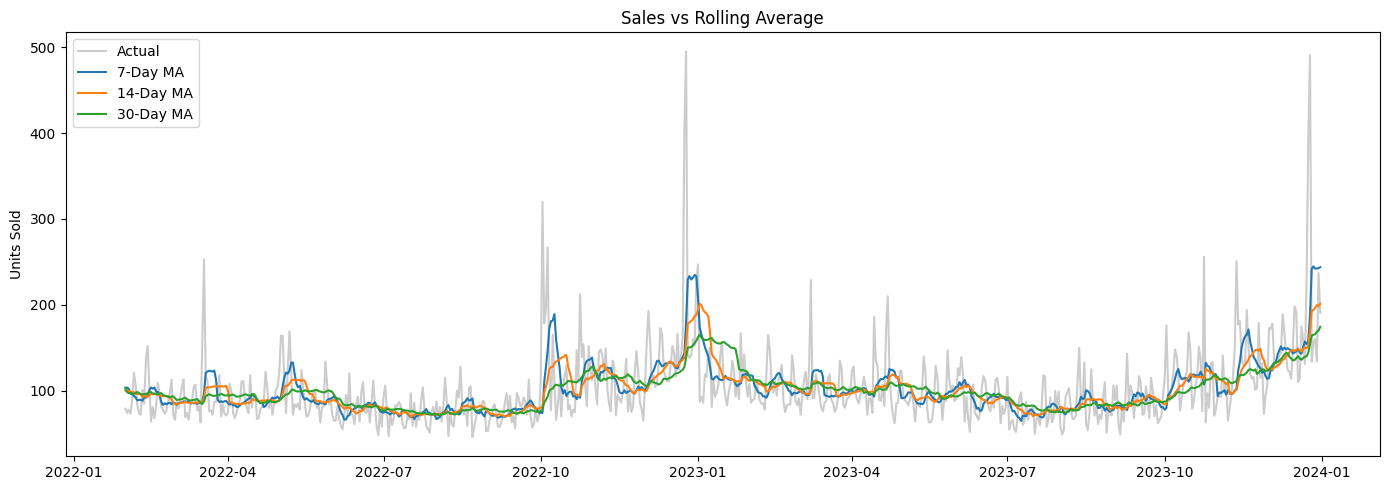

In [34]:
# Remove NaN
data = df.dropna()

# Plot
plt.figure(figsize=(14,5))

plt.plot(data.index, data['sales'], color='gray', alpha=0.4, label='Actual')
plt.plot(data.index, data['rolling_mean_7'], label='7-Day MA')
plt.plot(data.index, data['rolling_mean_14'], label='14-Day MA')
plt.plot(data.index, data['rolling_mean_30'], label='30-Day MA')

plt.title('Sales vs Rolling Average')
plt.ylabel('Units Sold')
plt.legend()

plt.tight_layout()
plt.savefig('reports/09_rolling_features.png')

plt.show()